Una vez que el motor en C++ funciona, los datos pueden recolectarse y mostrarse adecuadamente en Python. El primer paso es por tanto la carga de los datos y su observación inicial.

In [1]:
import pandas as pd
df = pd.read_csv(r"D:\Documentos\Portafolio\LastFM\LastFM\data\raw\Scrobbles_limpios.csv")
print(df.shape)
print(df.dtypes)
print(df.head())

(168689, 7)
uts             int64
artista           str
artist_mbid       str
cancion           str
cancion_mbid      str
album             str
album_mbid        str
dtype: object
          uts      artista                           artist_mbid  \
0  1776956566         Eels  14387b0f-765c-4852-852f-135335790466   
1  1776956348    Dr. Kelso                                   NaN   
2  1776916866    Colin Hay  864d7069-57dc-45f6-b408-875b35106dd3   
3  1776916621  Cheap Trick  9f870653-72b0-4c6d-8c59-439a95963e09   
4  1776916370  Cheap Trick  9f870653-72b0-4c6d-8c59-439a95963e09   

                 cancion                          cancion_mbid  \
0          Fresh Feeling  0572352f-77b6-4684-807f-4cc0044b4d92   
1    My Tuscaloosa Heart                                   NaN   
2        Beautiful World  cc9d0eb1-93d3-4b48-95ab-70c2a414d9ca   
3              Surrender                                   NaN   
4  I Want You to Want Me                                   NaN   

             a

Si bien el motor elimina errores evidentes y estructura el documento para que Python pueda luego leerlo, existen ligeros problemas que deben resolverse, por ejemplo, fechas que no han sido bien manejadas por LastFM

In [2]:
df["fecha"] = pd.to_datetime(df["uts"], unit="s") # Cambia el tipo de variable a objetos de fecha
print(df["fecha"].min()) # La fecha más reciente, la más antigua y las primeras 10
print(df["fecha"].max())
print(df["fecha"].sort_values().head(10))

1970-01-01 00:00:01
2026-04-23 15:02:46
168688   1970-01-01 00:00:01
168687   1970-01-01 00:00:02
168686   1970-01-01 00:00:03
168685   1970-01-01 00:00:04
168684   1970-01-01 00:00:05
168683   1970-01-01 00:00:06
168682   1970-01-01 00:00:07
168681   1970-01-01 00:00:08
168680   1970-01-01 00:00:09
168679   1970-01-01 00:00:10
Name: fecha, dtype: datetime64[s]


Se puede ver que existen fechas incorrectas, de 1970, por lo que se necesita encontrar los registros corruptos para descartarlos

In [4]:
# Cuántos registros tienen fecha anterior a 2005 (imposible para Last.fm)
corruptos = df[df["fecha"] < "2005-01-01"]
print(f"Registros corruptos: {len(corruptos)}") # f sirve para que se evalúen las expresiones dentro de las llaves {}
print(f"Registros totales: {len(df)}") # Cuántos registros hay en total, para luego ver el porcentaje, en el análisis en R ~0.4%
print(f"Porcentaje: {len(corruptos)/len(df)*100:.2f}%")

Registros corruptos: 480
Registros totales: 168689
Porcentaje: 0.28%


Ahora se revisan las NAs, posiblemente las que causan la ligera disonancia con los resultados en R

In [5]:
print(df.isnull().sum()) # NAs en cada columna

print(f"\nNAs en la columna UTS original:{df['uts'].isnull().sum()}")

uts                 0
artista           294
artist_mbid     51706
cancion           322
cancion_mbid    46340
album           13792
album_mbid      67698
fecha               0
dtype: int64

NAs en la columna UTS original:0


Para este proyecto las IDs faltantes no son relevantes, pueden ignorarse. Para ~170k registros, la cantidad de canciones y artistas faltantes no son inconveniente, aunque son un hueco un poco más importante (~13%) para los álbumes. Sigue eliminar todos estos registros corruptos.

In [6]:
df_limpio = df[
    (df["fecha"] >= "2005-01-01") &
    (df["artista"].notna()) &
    (df["cancion"].notna())
].copy() # Se trabaja ahora con una copia para no afecta a la variable original

print(f"Registros originales: {len(df)}")
print(f"\nRegistros limpios: {len(df_limpio)}")
print(f"\nRegistros eliminados: {len(df) - len(df_limpio)}")
print(f"\nRango de fechas: ")
print(df_limpio["fecha"].min())
print(df_limpio["fecha"].max())

Registros originales: 168689

Registros limpios: 167613

Registros eliminados: 1076

Rango de fechas: 
2008-09-09 00:38:06
2026-04-23 15:02:46


Si bien de forma pragmática se conoce la existencia de tres épocas, es importante resaltarlas con claridad aquí también.

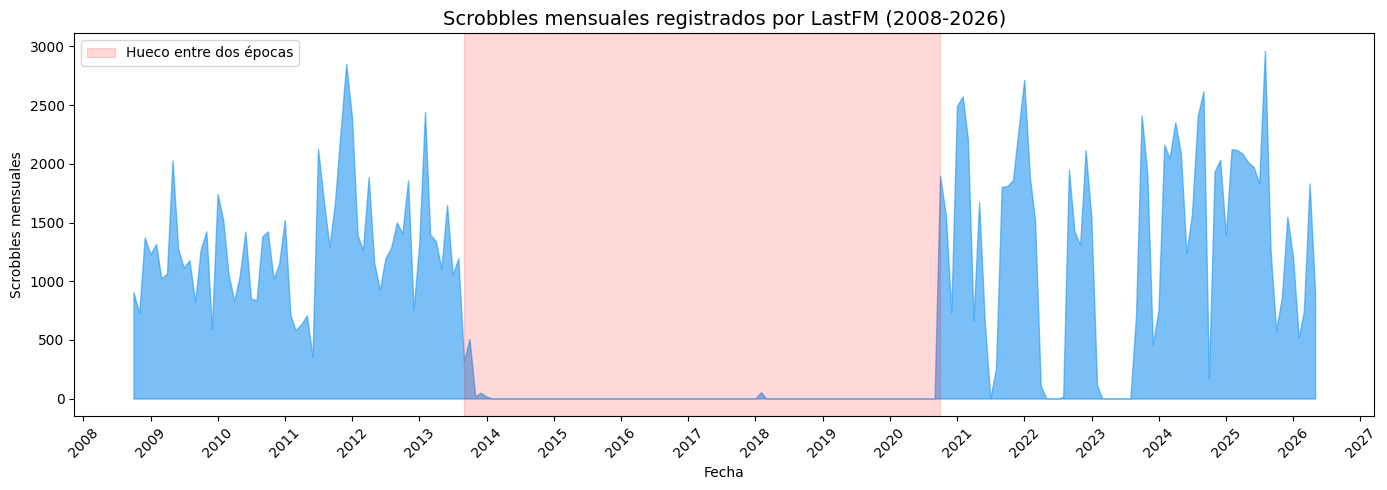

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_mensual = df_limpio.set_index("fecha").resample("ME").size()

fig, ax = plt.subplots(figsize = (14, 5))

ax.fill_between(df_mensual.index, df_mensual.values, alpha = 0.6, color = "#2196F3")
ax.axvspan(pd.Timestamp("2013-09-01"), pd.Timestamp("2020-10-01"),
           alpha = 0.15, color = "red", label = "Hueco entre dos épocas")

ax.set_title("Scrobbles mensuales registrados por LastFM (2008-2026)", fontsize = 14)
ax.set_xlabel("Fecha")
ax.set_ylabel("Scrobbles mensuales")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation = 45)
ax.legend()
plt.tight_layout()
plt.show()

Está claro que la caída en 2013 fue paulatina pero fuerte, bajando, subiendo un poco después para luego desaparecer. Un dispositivo viejo conectado, parece marcar un muy pequeño pico luego a inicios de 2018, pero no hay actividad sino hasta mediados de 2020.
Se ve hasta un poco caótico, pero el análisis previo demostró que es solo en apariencia, pues un modelo AR(1) fácilmente puede explicar la primera época, y uno AR(0) sin requerir imputaciones puede predecir el segundo.

In [8]:
epoca1 = df_limpio[(df_limpio["fecha"] >= "2005-01-01") &
                   (df_limpio["fecha"]<= "2013-09-01")].copy()

epoca2 = df_limpio[(df_limpio["fecha"] >= "2013-09-01") &
                   (df_limpio["fecha"]<= "2020-10-01")].copy()

epoca3 = df_limpio[df_limpio["fecha"] >= "2020-10-01"].copy()

sfdsf

In [10]:
print(epoca1["fecha"].max())
print(epoca3["fecha"].min())
print(f"\nÚltimos 6 meses época 1:")
print(epoca1[epoca1["fecha"] >= "2012-07-01"].groupby(epoca1["fecha"].dt.to_period("M")).size())
print(f"\nPrimeros 12 meses época 3:")
print(epoca3[epoca3["fecha"] <= "2021-10-01"].groupby(epoca3["fecha"].dt.to_period("M")).size())

2013-08-31 17:19:13
2020-10-01 00:02:55

Últimos 6 meses época 1:
fecha
2012-07    1283
2012-08    1501
2012-09    1408
2012-10    1860
2012-11     754
2012-12    1325
2013-01    2442
2013-02    1398
2013-03    1341
2013-04    1109
2013-05    1650
2013-06    1053
2013-07    1195
2013-08     319
Freq: M, dtype: int64

Primeros 12 meses época 3:
fecha
2020-10    1567
2020-11     735
2020-12    2493
2021-01    2575
2021-02    2213
2021-03     664
2021-04    1674
2021-05     651
2021-07     255
2021-08    1803
2021-09    1811
Freq: M, dtype: int64


Conocido esto, es posible establecer cada época provisionalmente. Ahora es posible determinar si tiene sentido que cada época extrema "done" parte de sus datos a la época 2 para luego poder imputar los datos de este hueco.

In [11]:
serie_mensual1 = epoca1.set_index("fecha").resample("ME").size()
serie_mensual3 = epoca3.set_index("fecha").resample("ME").size()

print(f"Época 1: {len(serie_mensual1)} meses")
print(f"Época 3: {len(serie_mensual3)} meses")

ceros_mensual1 = (serie_mensual1 == 0).sum()
ceros_mensual3 = (serie_mensual3 == 0).sum()

print(f"Para la época 1 hay: {ceros_mensual1}, con un total de {len(serie_mensual1)}")
print(f"Para la época 3 hay: {ceros_mensual3}, con un total de {len(serie_mensual3)}")


Época 1: 60 meses
Época 3: 67 meses
Para la época 1 hay: 0, con un total de 60
Para la época 3 hay: 10, con un total de 67


Conociendo esta extensión es más seguro realizar la ACF y la PACF, pues si se tratara de series más cortas potencialmente podría haber inconvenientes.

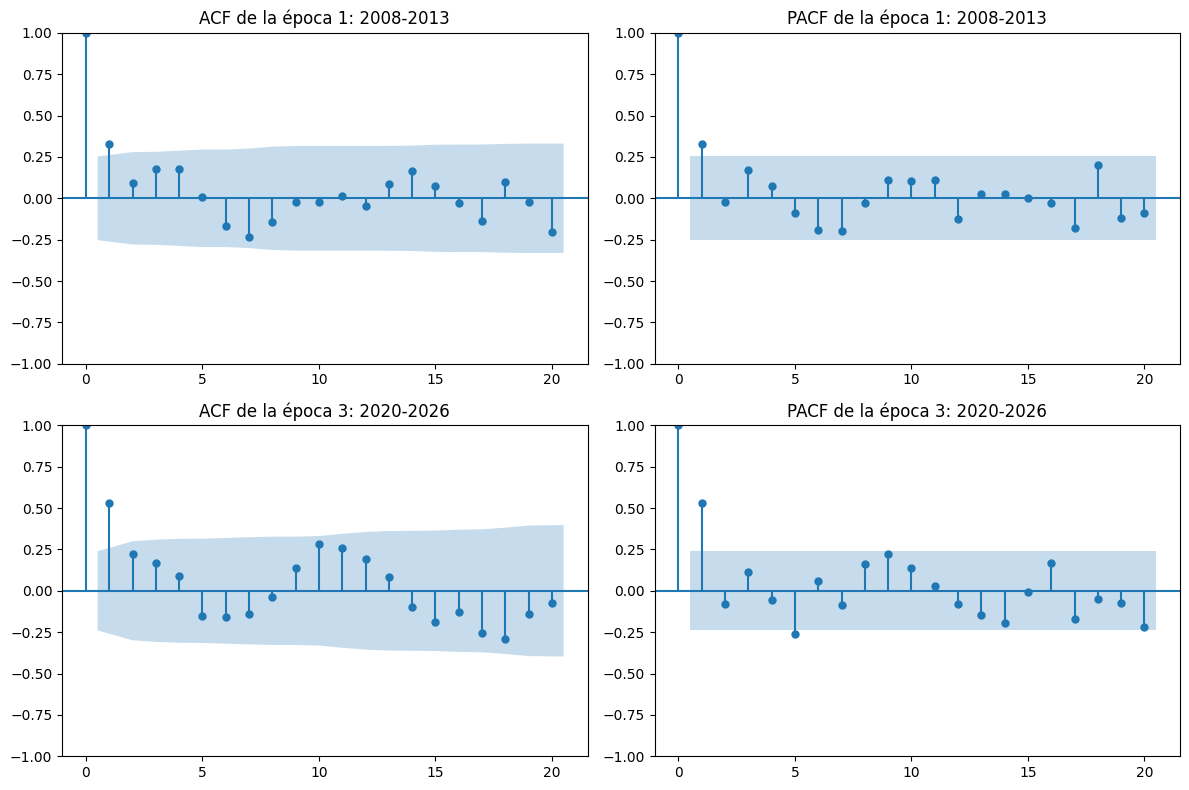

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize = (12,8))

plot_acf(serie_mensual1, lags = 20, ax = axes[0,0], title = "ACF de la época 1: 2008-2013")
plot_pacf(serie_mensual1, lags = 20, ax = axes[0,1], title = "PACF de la época 1: 2008-2013")
plot_acf(serie_mensual3, lags = 20, ax = axes[1,0], title = "ACF de la época 3: 2020-2026")
plot_pacf(serie_mensual3, lags = 20, ax = axes[1,1], title = "PACF de la época 3: 2020-2026")

plt.tight_layout()
plt.show()

En este caso, dado que el segundo rezago es el único que queda fuera, se puede entender que hay una memoria corta, y por tanto se tratará muy potencialmente de un modelo AR, uno MA o un ARIMA el que pronostique fielmente la serie. En el análisis realizado en R, el resultado final es precisamente un AR(1) para la época 1 y un AR(0) para la 2.

---------------Serie diaria----------------

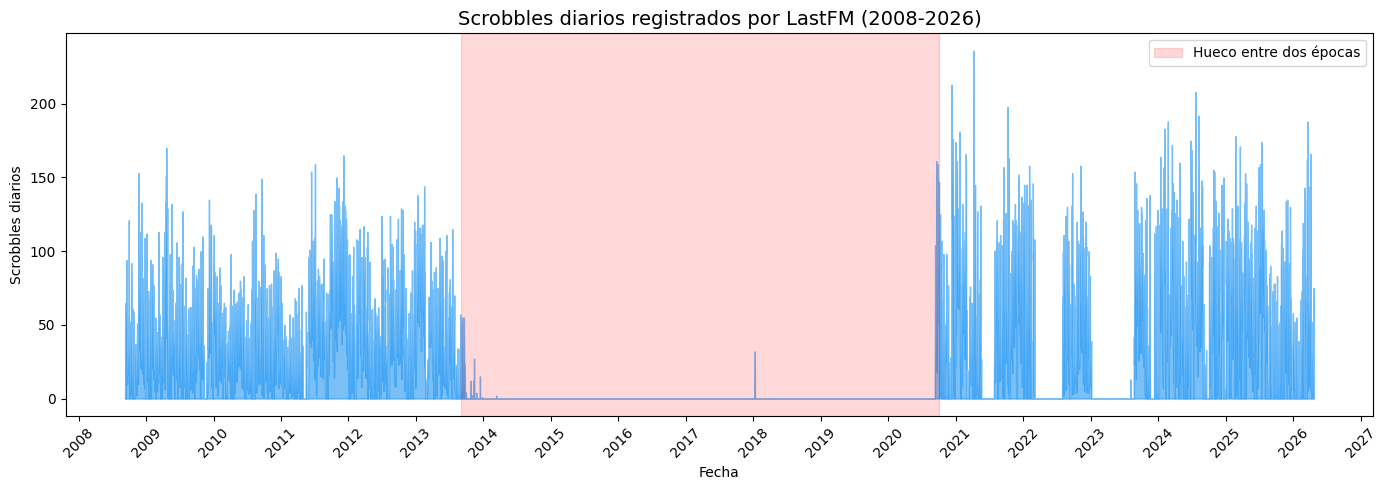

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_mensual = df_limpio.set_index("fecha").resample("D").size()

fig, ax = plt.subplots(figsize = (14, 5))

ax.fill_between(df_mensual.index, df_mensual.values, alpha = 0.6, color = "#2196F3")
ax.axvspan(pd.Timestamp("2013-09-01"), pd.Timestamp("2020-10-01"),
           alpha = 0.15, color = "red", label = "Hueco entre dos épocas")

ax.set_title("Scrobbles diarios registrados por LastFM (2008-2026)", fontsize = 14)
ax.set_xlabel("Fecha")
ax.set_ylabel("Scrobbles diarios")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation = 45)
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
serie_diaria1 = epoca1.set_index("fecha").resample("D").size()
serie_diaria3 = epoca3.set_index("fecha").resample("D").size()

print(f"Época 1: {len(serie_diaria1)} dias")
print(f"Época 3: {len(serie_diaria3)} dias")

Época 1: 1818 dias
Época 3: 2031 dias


Cuántos ceros tiene la serie diaria?

In [17]:
ceros_diaria1 = (serie_diaria1 == 0).sum()
ceros_diaria3 = (serie_diaria3 == 0).sum()

print(f"Para la época 1 hay: {ceros_diaria1}, con un total de {len(serie_diaria1)}")
print(f"Para la época 3 hay: {ceros_diaria3}, con un total de {len(serie_diaria3)}")


Para la época 1 hay: 165, con un total de 1818
Para la época 3 hay: 699, con un total de 2031


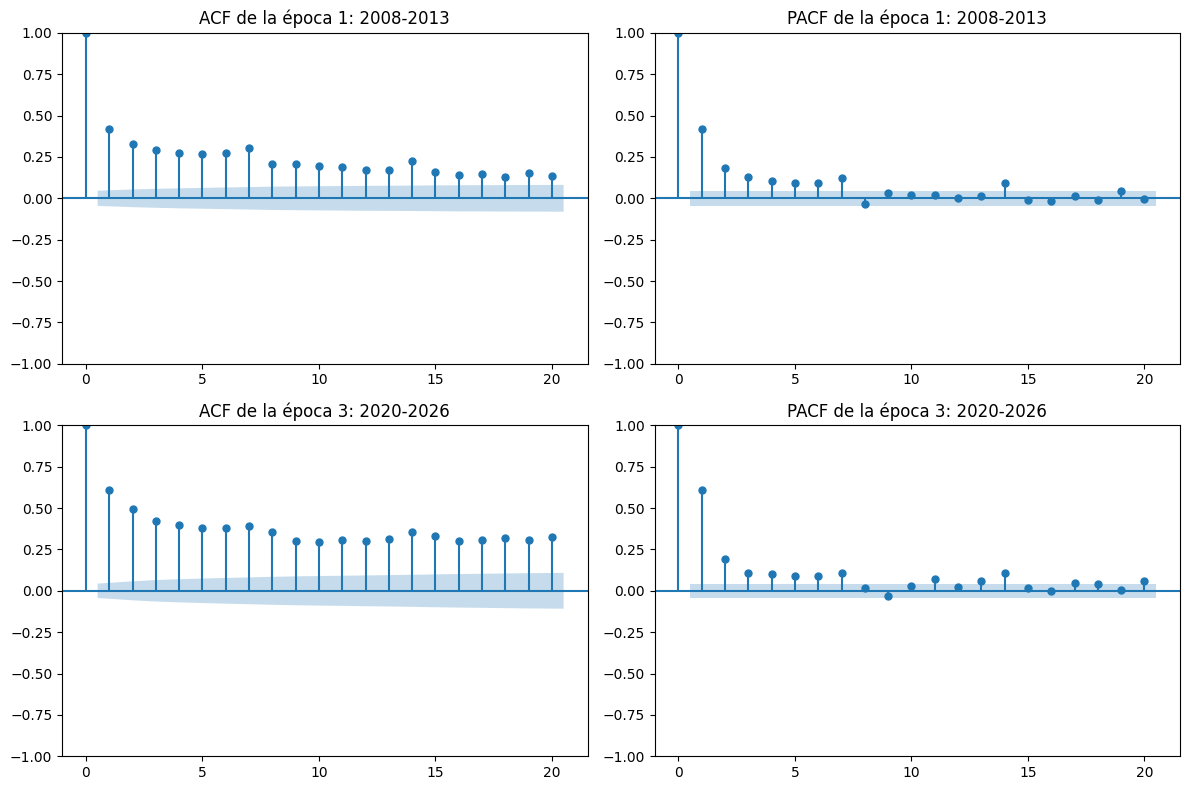

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize = (12,8))

plot_acf(serie_diaria1, lags = 20, ax = axes[0,0], title = "ACF de la época 1: 2008-2013")
plot_pacf(serie_diaria1, lags = 20, ax = axes[0,1], title = "PACF de la época 1: 2008-2013")
plot_acf(serie_diaria3, lags = 20, ax = axes[1,0], title = "ACF de la época 3: 2020-2026")
plot_pacf(serie_diaria3, lags = 20, ax = axes[1,1], title = "PACF de la época 3: 2020-2026")

plt.tight_layout()
plt.show()

Dado que se muestra con mucha claridad que hay memoria, se evalúa el exponente de Hurst, pues hay evidencia para pensar que se trata de una serie mucho más compleja.

In [24]:
import numpy as np

def dfa(series, L):
    """
    series: datos de escuchas diarias
    L: lista de tamaños de ventana (ej. [10, 20, 40, 80...])
    """
    # 1. Integrar la serie (restando la media para centrarla)
    y = np.cumsum(series - np.mean(series))
    
    fluctuations = []
    for l in L:
        # 2. Dividir en ventanas de tamaño 'l'
        num_windows = len(y) // l
        rms = []
        for i in range(num_windows):
            window = y[i*l : (i+1)*l]
            x = np.arange(l)
            # 3. Ajuste lineal (polinomio grado 1) para quitar la tendencia
            # poly = np.polyfit(x, window, 1)
            # polinomio grado 1 no parece ser suficiente
            poly = np.polyfit(x, window, 3)  # grado 2 en lugar de 1
            trend = np.polyval(poly, x)
            # 4. Calcular el RMS (Error cuadrático medio)
            rms.append(np.sqrt(np.mean((window - trend)**2)))
        fluctuations.append(np.mean(rms))
    
    # 5. El exponente de Hurst es la pendiente en escala log-log
    coeffs = np.polyfit(np.log(L), np.log(fluctuations), 1)
    return coeffs[0], L, fluctuations

# Definimos los tamaños de las ventanas (de 1 semana a 6 meses aprox)
ventanas = np.logspace(1, 2.5, 15, dtype=int)

# Calculamos para Época 1 y Época 3
alpha1, L1, F1 = dfa(epoca1.set_index("fecha").resample("D").size(), ventanas)
alpha3, L3, F3 = dfa(epoca3.set_index("fecha").resample("D").size(), ventanas)

print(f"Exponente de Hurst (Alpha) Época 1: {alpha1:.3f}")
print(f"Exponente de Hurst (Alpha) Época 3: {alpha3:.3f}")

Exponente de Hurst (Alpha) Época 1: 0.865
Exponente de Hurst (Alpha) Época 3: 0.954


In [21]:
from hurst import compute_Hc

# Reemplaza ceros con NaN para no contaminar el cálculo
serie3_hurst = serie_diaria3.replace(0, float('nan')).dropna()
serie1_hurst = serie_diaria1.replace(0, float('nan')).dropna()

H1, c1, _ = compute_Hc(serie1_hurst, kind='change', simplified=True)
H3, c3, _ = compute_Hc(serie3_hurst, kind='change', simplified=True)

print(f"Hurst época 1: {H1:.4f}")
print(f"Hurst época 3: {H3:.4f}")

Hurst época 1: 0.9526
Hurst época 3: 0.9696


Un Hurst tan alto muestra definitoriamente persistencia. Esto tiene sentido, puesto que las escuchas guardan una relación muy profunda. Una sesión de escuchas de 2 horas hará que sea más probable que se escuche una canción más, mientras que un silencio de la misma duración opondrá resistencia a una escucha nueva. Por ello, resulta importante entender las PDF, Probability density function de los bloques. Algo de particular interés es que el cálculo más manual muestra un $H = 1.042$, es decir, algo que supera los límites teóricos iniciales. Se trata de un fenómeno de superdifusividad en el que hay una caminata aleatoria con correlaciones, básicamente algo parecido a un ruido blanco, pero que se correlaciona de alguna forma.

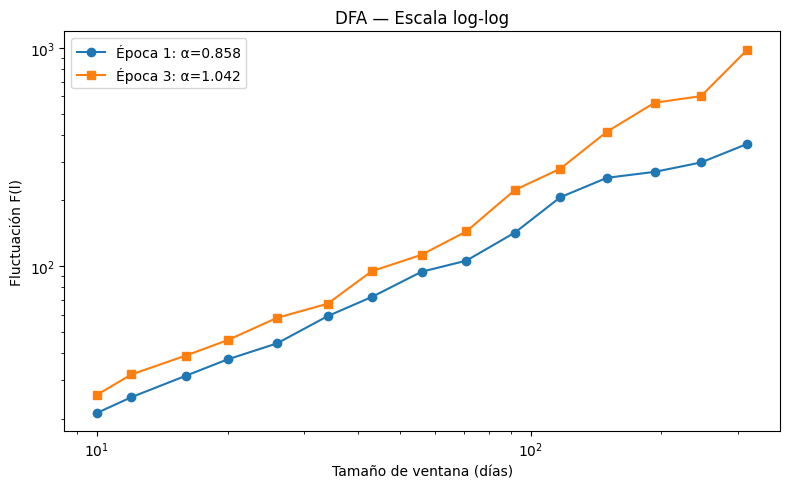

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(L1, F1, 'o-', label=f'Época 1: α={alpha1:.3f}')
ax.loglog(L3, F3, 's-', label=f'Época 3: α={alpha3:.3f}')
ax.set_xlabel('Tamaño de ventana (días)')
ax.set_ylabel('Fluctuación F(l)')
ax.set_title('DFA — Escala log-log')
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
from statsmodels.tsa.stattools import kpss

serie3_diaria = epoca3.set_index("fecha").resample("D").size()
serie1_diaria = epoca1.set_index("fecha").resample("D").size()

stat3, p3, lags3, _ = kpss(serie3_diaria, regression='ct', nlags='auto')
stat1, p1, lags1, _ = kpss(serie1_diaria, regression='ct', nlags='auto')

print(f"KPSS Época 1: estadístico={stat1:.4f}, p={p1:.3f}")
print(f"KPSS Época 3: estadístico={stat3:.4f}, p={p3:.3f}")

KPSS Época 1: estadístico=0.1494, p=0.047
KPSS Época 3: estadístico=0.2824, p=0.010


C:\Users\Ich\AppData\Local\Temp\ipykernel_17292\2298225049.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat3, p3, lags3, _ = kpss(serie3_diaria, regression='ct', nlags='auto')


In [27]:
from arch.unitroot import KPSS

lo1 = KPSS(serie1_diaria, trend='ct', lags='auto')
lo3 = KPSS(serie3_diaria, trend='ct', lags='auto')

print(lo1.summary())
print(lo3.summary())

ModuleNotFoundError: No module named 'arch'